# Fine-tuned Vision Transformer (ViT) model

In [134]:
from pathlib import Path
from collections import Counter
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## 0. prepare

In [113]:
# png to jpg
from PIL import Image
def convert_png_to_jpg(image_path):
    image = Image.open(image_path).convert("RGB")
    # 不用save，直接返回RGB格式的image对象，后续DataLoader里再进行transform
    return image

## 1. load train / test data

In [114]:
# 加载 classification 数据（calli-kaggle）
data_root = Path("calli-kaggle/data/data")
if not data_root.exists():
    raise FileNotFoundError(f"未找到数据目录: {data_root.resolve()}")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def load_split(split_name: str):
    split_dir = data_root / split_name
    if not split_dir.exists():
        raise FileNotFoundError(f"未找到 split 目录: {split_dir}")

    class_names = sorted([p.name for p in split_dir.iterdir() if p.is_dir()])
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    samples = []
    for class_name in class_names:
        class_dir = split_dir / class_name
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                samples.append((str(p), class_to_idx[class_name], class_name))

    return class_names, class_to_idx, samples

train_classes, class_to_idx, train_samples = load_split("train")
test_classes, _, test_samples = load_split("test")

# train/test 类别一致性检查
if train_classes != test_classes:
    print("警告: train 和 test 的类别列表不一致")
else:
    print(f"类别数: {len(train_classes)}")
    print(f"类别名: {train_classes}")

train_counts = Counter([label_name for _, _, label_name in train_samples])
test_counts = Counter([label_name for _, _, label_name in test_samples])

print(f"train 样本数: {len(train_samples)}")
print(f"test 样本数: {len(test_samples)}")

print("\n各类别样本数（train / test）:")
for c in train_classes:
    print(f"{c:>6}: {train_counts.get(c, 0):>4} / {test_counts.get(c, 0):>4}")

# 随机查看几条样本路径
preview_n = min(5, len(train_samples))
print("\ntrain 样本示例:")
for path, label_idx, label_name in random.sample(train_samples, k=preview_n):
    print(f"label={label_idx:>2} ({label_name}) | {path}")

# 如果你后续要喂给模型，可直接使用：
X_train = [s[0] for s in train_samples]
y_train = [s[1] for s in train_samples]
X_test = [s[0] for s in test_samples]
y_test = [s[1] for s in test_samples]

print("\n已生成: X_train, y_train, X_test, y_test, class_to_idx")

类别数: 20
类别名: ['bdsr', 'csl', 'fwq', 'gj', 'htj', 'hy', 'lgq', 'lqs', 'lx', 'mf', 'mzd', 'oyx', 'sgt', 'shz', 'smh', 'wxz', 'wzm', 'yyr', 'yzq', 'zmf']
train 样本数: 84022
test 样本数: 21007

各类别样本数（train / test）:
  bdsr: 1588 /  397
   csl:  860 /  215
   fwq: 5410 / 1353
    gj: 5410 / 1353
   htj: 5371 / 1343
    hy: 2665 /  666
   lgq: 5410 / 1353
   lqs: 5406 / 1351
    lx: 5410 / 1353
    mf: 5410 / 1353
   mzd: 5410 / 1353
   oyx: 2808 /  702
   sgt: 5001 / 1250
   shz: 5410 / 1353
   smh: 1014 /  253
   wxz: 5393 / 1348
   wzm: 3621 /  905
   yyr: 5410 / 1353
   yzq: 5405 / 1351
   zmf: 1610 /  402

train 样本示例:
label=12 (sgt) | calli-kaggle/data/data/train/sgt/0293.jpg
label=10 (mzd) | calli-kaggle/data/data/train/mzd/0360.jpg
label=11 (oyx) | calli-kaggle/data/data/train/oyx/0595.jpg
label= 3 (gj) | calli-kaggle/data/data/train/gj/5355.jpg
label= 5 (hy) | calli-kaggle/data/data/train/hy/1330.jpg

已生成: X_train, y_train, X_test, y_test, class_to_idx


In [115]:
train_samples[:5]

[('calli-kaggle/data/data/train/bdsr/0071.jpg', 0, 'bdsr'),
 ('calli-kaggle/data/data/train/bdsr/0717.jpg', 0, 'bdsr'),
 ('calli-kaggle/data/data/train/bdsr/1409.jpg', 0, 'bdsr'),
 ('calli-kaggle/data/data/train/bdsr/0703.jpg', 0, 'bdsr'),
 ('calli-kaggle/data/data/train/bdsr/0065.jpg', 0, 'bdsr')]

In [116]:
style_summary_df = pd.read_csv("calli-kaggle/Summary.csv")
master_match_dict = dict(zip(style_summary_df["Label"], style_summary_df["Calligrapher Name"]))
print(master_match_dict)
print(class_to_idx)
total_classes = len(master_match_dict)
print(f"总类别数: {total_classes}")

{'wxz': '王羲之', 'yzq': '颜真卿', 'lgq': '柳公权', 'sgt': '孙过庭', 'smh': '沙孟海', 'mf': '米芾', 'htj': '黄庭坚', 'oyx': '欧阳询', 'zmf': '赵孟頫', 'csl': '褚遂良', 'wzm': '文征明', 'lqs': '梁秋生', 'yyr': '于右任', 'hy': '弘一', 'bdsr': '八大山人', 'fwq': '范文强', 'gj': '管峻', 'shz': '宋徽宗', 'mzd': '毛泽东', 'lx': '鲁迅'}
{'bdsr': 0, 'csl': 1, 'fwq': 2, 'gj': 3, 'htj': 4, 'hy': 5, 'lgq': 6, 'lqs': 7, 'lx': 8, 'mf': 9, 'mzd': 10, 'oyx': 11, 'sgt': 12, 'shz': 13, 'smh': 14, 'wxz': 15, 'wzm': 16, 'yyr': 17, 'yzq': 18, 'zmf': 19}
总类别数: 20


In [117]:
# 检查图片大小
# 使用calli-kaggle/data/data/train/bdsr/0065.jpg
from PIL import Image
img_path = "calli-kaggle/data/data/train/bdsr/0065.jpg"
with Image.open(img_path) as img:
    print(f"图片大小: {img.size}")  # 输出 (width, height)

图片大小: (64, 64)


## 2. prepare the Vit model

In [119]:
from transformers import ViTForImageClassification, ViTImageProcessor

model_name = "google/vit-base-patch16-224"

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=total_classes,
    id2label={i: label for label, i in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([20, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [120]:
# fine-tuning
print(len(model.vit.encoder.layer))


12


In [121]:
# 选择是否解冻部分 ViT 层进行微调
def freeze_vit_layers(model, n_unfreeze=0, train_classifier=True):
    # 冻结所有参数
    for param in model.parameters():
        param.requires_grad = False

    # 解冻最后 n_unfreeze 个 encoder block
    if n_unfreeze > 0:
        for layer in model.vit.encoder.layer[-n_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True

    # 解冻分类头
    if train_classifier:
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model
    

In [122]:
# 选择解冻最后 2 个 ViT 层 + 分类头进行微调
model = freeze_vit_layers(model, n_unfreeze=4, train_classifier=True)

# 进行 train + test
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

class CalligraphyDataset(Dataset):
    def __init__(self, image_paths, labels, processor):
        self.image_paths = image_paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt") # 自动resize + normalization
        pixel_values = inputs["pixel_values"].squeeze(0)
        label = self.labels[idx]
        return pixel_values, label

def collate_fn(batch):
    pixel_values, labels = zip(*batch)
    pixel_values = torch.stack(pixel_values)
    labels = torch.tensor(labels, dtype=torch.long)
    return pixel_values, labels

In [123]:
# 你可以调大这两个值做完整训练
# 直接全部
max_train_samples = 100000
max_test_samples = 100000

rng = np.random.default_rng(42)
train_idx = rng.choice(len(X_train), size=min(max_train_samples, len(X_train)), replace=False)
test_idx = rng.choice(len(X_test), size=min(max_test_samples, len(X_test)), replace=False)

train_paths = [X_train[i] for i in train_idx]
train_labels = [y_train[i] for i in train_idx]
test_paths = [X_test[i] for i in test_idx]
test_labels = [y_test[i] for i in test_idx]

train_dataset = CalligraphyDataset(train_paths, train_labels, processor)
test_dataset = CalligraphyDataset(test_paths, test_labels, processor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_fn)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model = model.to(device)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-5)

epochs = 2
print(f"Device: {device}")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]")
    for pixel_values, labels in pbar:
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = running_loss / len(train_loader)

    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        pbar_eval = tqdm(test_loader, desc=f"Epoch {epoch + 1}/{epochs} [Eval]")
        for pixel_values, labels in pbar_eval:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            eval_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_eval_loss = eval_loss / len(test_loader)
    acc = correct / total if total > 0 else 0.0
    print(f"Epoch {epoch + 1}: train_loss={avg_train_loss:.4f}, eval_loss={avg_eval_loss:.4f}, eval_acc={acc:.4f}")

Device: mps
Train samples: 84022 | Test samples: 21007


Epoch 1/2 [Train]:   0%|          | 0/1313 [00:00<?, ?it/s]

Epoch 1/2 [Eval]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 1: train_loss=0.3723, eval_loss=0.0891, eval_acc=0.9754


Epoch 2/2 [Train]:   0%|          | 0/1313 [00:00<?, ?it/s]

Epoch 2/2 [Eval]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 2: train_loss=0.0618, eval_loss=0.0693, eval_acc=0.9791


In [133]:
save_dir = "./vit_calligraphy_best"

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./vit_calligraphy_best/preprocessor_config.json']

Generating predictions for confusion matrix:   0%|          | 0/329 [00:00<?, ?it/s]

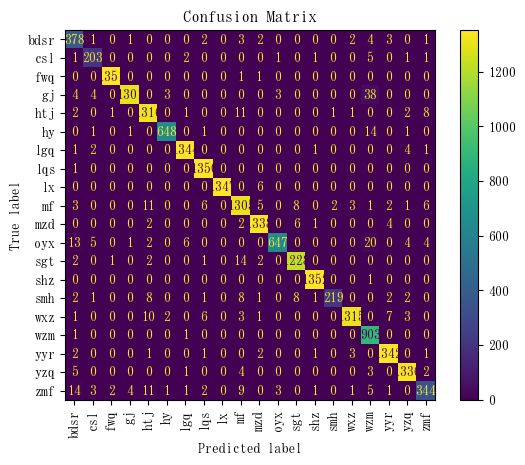

In [127]:
# 输出混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for pixel_values, labels in tqdm(test_loader, desc="Generating predictions for confusion matrix"):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_classes)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()